# META 1-Minute Direction Prediction — Public Companion Notebook

This is the executable companion to [When Sequence Models Meet Market Noise](https://adidror005.github.io/sequence-models-for-prediction/15-finance-direction-case-study.html). It contains the saved single-symbol experiment reported in the article: causal features, whole-session chronological splits, a training-only movement cutoff, lazy 78-bar sequences, six PyTorch classifiers, an MLP feature ablation, and a CatBoost endpoint baseline.

The saved outputs come from one META run with seed 42. They are classification results, not a trading backtest. Market data is not redistributed in this repository; provide your own licensed regular-trading-hours Parquet bars using the layout and schema documented in [`notebooks/README.md`](README.md).

The original notebook included multi-symbol scaffolding plus unfinished inference and technical-analysis experiments. This public edition fixes `SYMBOLS = ["META"]` to match the recorded run and ends after the reported CatBoost comparison.

## Prediction contract

At minute `t`, the target is the next close-to-close return: `close[t+1] / close[t] - 1`. Labels are `-1/+1`; small absolute moves are ignored. The cutoff is fitted on training data only. Each example contains 78 consecutive one-minute bars ending at `t`, and its target is the move from `t` to `t+1`.


## 1. Imports and configuration

In [1]:
import math
import random
from copy import deepcopy
import duckdb
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset

from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

duckdb.sql("SET TimeZone = 'America/New_York'")

SYMBOLS = ["META"]
FOCUS_SYMBOL = "META"
DATA_GLOB = "data/{symbol}/1_min_TRADES_RTH/*.parquet"

TARGET_HORIZON_MINUTES = 1
DROP_FRACTION = 0.35
SYMBOL_CUTOFF_BLEND = 0.75

TRAIN_FRAC = 0.75
VAL_FRAC = 0.10

SEQ_LEN = 78
BATCH_SIZE = 512
SYMBOL_EMBED_DIM = min(8, max(1, len(SYMBOLS)))

DEVICE_OVERRIDE = None  # e.g. "cpu" to debug MPS separately
USE_POS_WEIGHT = False

EPOCHS = 20
EARLY_STOP_PATIENCE = 2
MIN_EPOCHS_BEFORE_STOPPING = 3

RUN_MODELS = ["MLP", "LSTM", "GRU", "CNN1D", "TCN", "Transformer"]

# Price-memory / regularization settings
RUN_BASE_MLP_ABLATION = True
INCLUDE_RAW_LOG_CLOSE = False  # raw level can proxy time/regime across a long multi-symbol history
DROPOUT = 0.20
WEIGHT_DECAY = 1e-3


def choose_device():
    if DEVICE_OVERRIDE is not None:
        return torch.device(DEVICE_OVERRIDE)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = choose_device()

print("PyTorch:", torch.__version__)
print("Device:", device)
print("Symbols:", SYMBOLS)


PyTorch: 2.12.0
Device: mps
Symbols: ['META']


## 2. Load raw one-minute RTH bars

In [2]:
raw_frames = {}

for symbol in SYMBOLS:
    path = DATA_GLOB.format(symbol=symbol)
    one = duckdb.sql(f"""
        SELECT *
        FROM read_parquet('{path}', union_by_name=true)
        ORDER BY date
    """).to_df()

    if one.empty:
        raise ValueError(f"No rows loaded for {symbol}: {path}")

    one["date"] = pd.to_datetime(one["date"])
    one = one.sort_values("date").drop_duplicates("date").set_index("date")

    required = {"open", "high", "low", "close", "volume"}
    missing = required - set(one.columns)
    if missing:
        raise ValueError(f"{symbol} missing required columns: {sorted(missing)}")

    raw_frames[symbol] = one

for symbol, one in raw_frames.items():
    print(f"{symbol:>6}: {len(one):,} rows | {one.index.min()} -> {one.index.max()}")

  META: 1,335,228 rows | 2013-01-02 09:30:00-05:00 -> 2026-09-02 09:47:00-04:00


## 3. Causal features + explicit one-minute target

The real feature list cannot contain any future-return or label field. Intraday rolling features reset each session where appropriate, while the longer-memory relative-price features deliberately span sessions using only current and past RTH bars.

The target at row `t` is `close[t+1] / close[t] - 1`.

This version deliberately **does not use fractional differentiation**. Longer price context is represented with relative features such as distance from the previous session close, rolling log-price means, and a rolling log-price z-score.


In [3]:
EPS = 1e-12


def engineer_symbol_frame(raw, symbol):
    x = raw.copy().sort_index()
    x["symbol"] = symbol
    x["session_date"] = pd.DatetimeIndex(x.index).date
    g = x.groupby("session_date", sort=False)

    # ------------------------------------------------------------------
    # Target: next-minute close-to-close return within the same session.
    # ------------------------------------------------------------------
    future_close = g["close"].shift(-TARGET_HORIZON_MINUTES)
    x["future_close"] = future_close
    x["future_return"] = future_close / x["close"] - 1.0

    ts = pd.Series(pd.DatetimeIndex(x.index), index=x.index)
    x["future_timestamp"] = ts.groupby(x["session_date"], sort=False).shift(
        -TARGET_HORIZON_MINUTES
    )

    # ------------------------------------------------------------------
    # Original short-horizon features.
    # ------------------------------------------------------------------
    prev_close = g["close"].shift(1)
    x["ret_1"] = x["close"] / prev_close - 1.0
    x["ret_2"] = x["close"] / g["close"].shift(2) - 1.0
    x["ret_5"] = x["close"] / g["close"].shift(5) - 1.0
    x["ret_15"] = x["close"] / g["close"].shift(15) - 1.0

    x["candle_body"] = x["close"] / x["open"] - 1.0
    x["range_pct"] = x["high"] / x["low"] - 1.0
    x["gap_from_prev_close"] = x["open"] / prev_close - 1.0
    x["close_location"] = (
        (x["close"] - x["low"]) /
        (x["high"] - x["low"] + EPS)
    )

    for w in [5, 15, 30, 60]:
        x[f"ret_mean_{w}"] = g["ret_1"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).mean()
        )
        x[f"ret_std_{w}"] = g["ret_1"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).std()
        )

    x["log_volume"] = np.log1p(x["volume"].clip(lower=0))
    lv_mean = g["log_volume"].transform(
        lambda s: s.rolling(30, min_periods=30).mean()
    )
    lv_std = g["log_volume"].transform(
        lambda s: s.rolling(30, min_periods=30).std()
    )
    x["volume_z_30"] = (
        (x["log_volume"] - lv_mean) /
        (lv_std + EPS)
    )

    for w in [5, 30]:
        vm = g["volume"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).mean()
        )
        x[f"relative_volume_{w}"] = (
            x["volume"] / (vm + EPS)
        )

    if "average" in x.columns:
        x["close_vs_average"] = x["close"] / x["average"] - 1.0
        x["average_vs_open"] = x["average"] / x["open"] - 1.0

    idx = pd.DatetimeIndex(x.index)
    minute_of_day = idx.hour * 60 + idx.minute
    minute_from_open = minute_of_day - (9 * 60 + 30)
    x["minute_from_open"] = minute_from_open.astype(float)
    phase = 2.0 * np.pi * minute_from_open / 390.0
    x["tod_sin"] = np.sin(phase)
    x["tod_cos"] = np.cos(phase)

    # ------------------------------------------------------------------
    # NEW: longer-memory price-state features.
    #
    # These intentionally do NOT reset each session. They use the stream of
    # observed RTH bars up through the current minute. That lets the model
    # know where the current price sits relative to longer price history
    # without giving it raw close/log(close) as a trending level.
    # ------------------------------------------------------------------
    log_close = np.log(x["close"].astype(float).clip(lower=EPS))
    # Optional raw log-price level. It is engineered but excluded from the default
    # model because a multi-year raw level can act as a proxy for calendar time /
    # regime and generalize poorly.
    x["log_close_level"] = log_close

    # Previous completed session close.
    daily_close = x.groupby("session_date", sort=False)["close"].last()
    prev_day_close_by_session = daily_close.shift(1)
    x["close_vs_prev_day_close"] = (
        x["close"] /
        x["session_date"].map(prev_day_close_by_session).astype(float)
        - 1.0
    )

    # Relative log-price location at multiple horizons.
    # 390 RTH minutes ~= 1 trading day.
    for bars, name in [
        (30, "30m"),
        (390, "1d"),
        (390 * 5, "5d"),
        (390 * 20, "20d"),
    ]:
        rolling_log_mean = log_close.rolling(
            bars, min_periods=bars
        ).mean()
        x[f"log_close_vs_ma_{name}"] = (
            log_close - rolling_log_mean
        )

    rolling_log_mean_1d = log_close.rolling(
        390, min_periods=390
    ).mean()
    rolling_log_std_1d = log_close.rolling(
        390, min_periods=390
    ).std()

    x["log_close_z_1d"] = (
        (log_close - rolling_log_mean_1d) /
        (rolling_log_std_1d + EPS)
    )


    return x.replace([np.inf, -np.inf], np.nan)


engineered_frames = {
    s: engineer_symbol_frame(raw_frames[s], s)
    for s in SYMBOLS
}

BASE_FEATURE_COLS = [
    "ret_1", "ret_2", "ret_5", "ret_15",
    "candle_body", "range_pct", "gap_from_prev_close", "close_location",
    "ret_mean_5", "ret_mean_15", "ret_mean_30", "ret_mean_60",
    "ret_std_5", "ret_std_15", "ret_std_30", "ret_std_60",
    "log_volume", "volume_z_30", "relative_volume_5", "relative_volume_30",
    "minute_from_open", "tod_sin", "tod_cos",
]

if all("average" in raw_frames[s].columns for s in SYMBOLS):
    BASE_FEATURE_COLS += [
        "close_vs_average",
        "average_vs_open",
    ]

PRICE_MEMORY_FEATURE_COLS = [
    "close_vs_prev_day_close",
    "log_close_vs_ma_30m",
    "log_close_vs_ma_1d",
    "log_close_vs_ma_5d",
    "log_close_vs_ma_20d",
    "log_close_z_1d",
]

if INCLUDE_RAW_LOG_CLOSE:
    PRICE_MEMORY_FEATURE_COLS += [
        "log_close_level",
    ]

FEATURE_COLS = (
    BASE_FEATURE_COLS +
    PRICE_MEMORY_FEATURE_COLS
)

FORBIDDEN_FEATURES = {
    "future_return",
    "future_close",
    "future_timestamp",
    "label",
    "label01",
    "label_cutoff",
}

assert not (
    set(FEATURE_COLS) &
    FORBIDDEN_FEATURES
)

print("Base features:", len(BASE_FEATURE_COLS))
print(BASE_FEATURE_COLS)
print("\nPrice-memory features:", len(PRICE_MEMORY_FEATURE_COLS))
print(PRICE_MEMORY_FEATURE_COLS)
print("\nEnhanced feature count:", len(FEATURE_COLS))


Base features: 25
['ret_1', 'ret_2', 'ret_5', 'ret_15', 'candle_body', 'range_pct', 'gap_from_prev_close', 'close_location', 'ret_mean_5', 'ret_mean_15', 'ret_mean_30', 'ret_mean_60', 'ret_std_5', 'ret_std_15', 'ret_std_30', 'ret_std_60', 'log_volume', 'volume_z_30', 'relative_volume_5', 'relative_volume_30', 'minute_from_open', 'tod_sin', 'tod_cos', 'close_vs_average', 'average_vs_open']

Price-memory features: 6
['close_vs_prev_day_close', 'log_close_vs_ma_30m', 'log_close_vs_ma_1d', 'log_close_vs_ma_5d', 'log_close_vs_ma_20d', 'log_close_z_1d']

Enhanced feature count: 31


## 4. Whole-session split, then training-only adaptive cutoffs

In [4]:
parts = []
for symbol in SYMBOLS:
    one = engineered_frames[symbol].rename_axis("date").reset_index()
    one = one.dropna(subset=FEATURE_COLS).copy()
    parts.append(one)

frame = pd.concat(parts, ignore_index=True)
frame["row_id"] = np.arange(len(frame), dtype=np.int64)
SYMBOL_TO_ID = {s: i for i, s in enumerate(SYMBOLS)}
frame["symbol_id"] = frame["symbol"].map(SYMBOL_TO_ID).astype(np.int64)


def split_by_session(df):
    tr, va, te = [], [], []
    for symbol in SYMBOLS:
        g = df[df["symbol"] == symbol].sort_values("date").copy()
        sessions = np.array(sorted(g["session_date"].unique()))
        if len(sessions) < 10:
            raise ValueError(f"{symbol}: only {len(sessions)} sessions")

        i1 = max(1, int(len(sessions) * TRAIN_FRAC))
        i2 = max(i1 + 1, int(len(sessions) * (TRAIN_FRAC + VAL_FRAC)))
        i2 = min(i2, len(sessions) - 1)

        tr_days = set(sessions[:i1])
        va_days = set(sessions[i1:i2])
        te_days = set(sessions[i2:])

        tr.append(g[g.session_date.isin(tr_days)])
        va.append(g[g.session_date.isin(va_days)])
        te.append(g[g.session_date.isin(te_days)])

    return (
        pd.concat(tr, ignore_index=True),
        pd.concat(va, ignore_index=True),
        pd.concat(te, ignore_index=True),
    )


train_df, val_df, test_df = split_by_session(frame)

for s in SYMBOLS:
    tr = set(train_df.loc[train_df.symbol == s, "session_date"])
    va = set(val_df.loc[val_df.symbol == s, "session_date"])
    te = set(test_df.loc[test_df.symbol == s, "session_date"])
    assert tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te)


def fit_cutoffs(train):
    valid = train.dropna(subset=["future_return"])
    pooled = float(valid["future_return"].abs().quantile(DROP_FRACTION))
    raw = {}
    final = {}
    for s in SYMBOLS:
        a = valid.loc[valid.symbol == s, "future_return"].abs()
        q = float(a.quantile(DROP_FRACTION))
        raw[s] = q
        final[s] = SYMBOL_CUTOFF_BLEND * q + (1.0 - SYMBOL_CUTOFF_BLEND) * pooled
    return pooled, raw, final


pooled_cutoff, raw_cutoffs, cutoffs = fit_cutoffs(train_df)


def apply_labels(df):
    out = df.copy()
    out["label_cutoff"] = out["symbol"].map(cutoffs).astype(float)
    out["label"] = np.nan
    out.loc[out.future_return > out.label_cutoff, "label"] = 1.0
    out.loc[out.future_return < -out.label_cutoff, "label"] = -1.0
    out["label01"] = np.where(out.label == 1.0, 1.0, np.where(out.label == -1.0, 0.0, np.nan))
    return out


train_df = apply_labels(train_df)
val_df = apply_labels(val_df)
test_df = apply_labels(test_df)

cutoff_table = pd.DataFrame({
    "symbol": SYMBOLS,
    "raw_symbol_cutoff_bps": [raw_cutoffs[s] * 10000 for s in SYMBOLS],
    "final_cutoff_bps": [cutoffs[s] * 10000 for s in SYMBOLS],
})
display(cutoff_table)


def summarize(name, df):
    print("\n" + name)
    for s in SYMBOLS:
        g = df[df.symbol == s]
        valid = g.future_return.notna()
        lab = g.label.notna()
        retained = lab.sum() / max(1, valid.sum())
        pos = (g.loc[lab, "label"] == 1).mean()
        print(f"{s:>6}: retained={retained:6.2%} | +1={pos:6.2%} | labeled={lab.sum():,}")

summarize("TRAIN", train_df)
summarize("VALIDATION", val_df)
summarize("TEST", test_df)

for df in (train_df, val_df, test_df):
    m = df.label.notna()
    assert set(df.loc[m, "label"].unique()).issubset({-1.0, 1.0})
    assert set(df.loc[m, "label01"].unique()).issubset({0.0, 1.0})
    assert np.all(np.sign(df.loc[m, "future_return"].to_numpy()) == df.loc[m, "label"].to_numpy())
    assert np.all(np.abs(df.loc[m, "future_return"].to_numpy()) > df.loc[m, "label_cutoff"].to_numpy())

print("\nSplit + cutoff + label assertions: PASSED")

,symbol,raw_symbol_cutoff_bps,final_cutoff_bps
0,META,2.228412,2.228412



TRAIN
  META: retained=65.00% | +1=50.24% | labeled=545,415

VALIDATION
  META: retained=68.21% | +1=50.54% | labeled=76,378

TEST
  META: retained=65.36% | +1=50.02% | labeled=109,728

Split + cutoff + label assertions: PASSED


## 5. Training-only selective scaling

The neural networks use the enhanced feature set. We do not blindly standardize every column.

The relative-price features with distribution-dependent magnitudes are standardized per symbol using training data only. The already standardized `log_close_z_1d` stays on its natural z-score scale.


In [5]:
# Selective neural-network preprocessing.
#
# Do NOT blindly StandardScale every feature. Some inputs are already normalized,
# bounded, ratios, or have a natural fixed scale. We only fit per-symbol scalers
# for distribution-dependent continuous features, using TRAINING DATA ONLY.

PER_SYMBOL_SCALE_COLS = [
    # short-horizon returns / ranges / realized-volatility features
    "ret_1", "ret_2", "ret_5", "ret_15",
    "candle_body", "range_pct", "gap_from_prev_close",
    "ret_mean_5", "ret_mean_15", "ret_mean_30", "ret_mean_60",
    "ret_std_5", "ret_std_15", "ret_std_30", "ret_std_60",
    "log_volume",

    # new price-memory features whose magnitude/distribution can differ by symbol
    "close_vs_prev_day_close",
    "log_close_vs_ma_30m",
    "log_close_vs_ma_1d",
    "log_close_vs_ma_5d",
    "log_close_vs_ma_20d",
]

if "log_close_level" in FEATURE_COLS:
    PER_SYMBOL_SCALE_COLS += [
        "log_close_level",
    ]

if "close_vs_average" in FEATURE_COLS:
    PER_SYMBOL_SCALE_COLS += [
        "close_vs_average",
        "average_vs_open",
    ]

# Intentionally not fit to StandardScaler:
#   close_location       -> roughly [0, 1]
#   volume_z_30          -> already a rolling z-score
#   relative_volume_*    -> already relative ratios
#   tod_sin/tod_cos      -> [-1, 1]
#   log_close_z_1d       -> already a rolling z-score
# minute_from_open gets a fixed transform below.
UNSCALED_FEATURE_COLS = [
    c for c in FEATURE_COLS
    if c not in PER_SYMBOL_SCALE_COLS
]

print(
    "Per-symbol standardized features:",
    PER_SYMBOL_SCALE_COLS,
)

print(
    "Not fitted to StandardScaler:",
    UNSCALED_FEATURE_COLS,
)

scalers = {}

for s in SYMBOLS:

    mask = train_df.symbol == s

    scaler = StandardScaler().fit(
        train_df.loc[
            mask,
            PER_SYMBOL_SCALE_COLS,
        ]
    )

    scalers[s] = scaler


def scale_split(df):

    out = df.copy()

    # Fixed, symbol-independent time transform.
    if "minute_from_open" in out.columns:
        out["minute_from_open"] = (
            out["minute_from_open"]
            .astype(np.float32) /
            390.0
        )

    for s in SYMBOLS:

        m = out.symbol == s

        out.loc[
            m,
            PER_SYMBOL_SCALE_COLS,
        ] = (
            scalers[s]
            .transform(
                out.loc[
                    m,
                    PER_SYMBOL_SCALE_COLS,
                ]
            )
            .astype(np.float32)
        )

    out.loc[:, FEATURE_COLS] = (
        out[FEATURE_COLS]
        .astype(np.float32)
    )

    return out


train_scaled = scale_split(train_df)
val_scaled = scale_split(val_df)
test_scaled = scale_split(test_df)

for name, df in [
    ("train", train_scaled),
    ("val", val_scaled),
    ("test", test_scaled),
]:

    arr = df[
        FEATURE_COLS
    ].to_numpy(dtype=np.float32)

    assert np.isfinite(arr).all(), (
        f"Non-finite input in {name}"
    )

print(
    "Finite selectively-scaled NN input checks: PASSED"
)


Per-symbol standardized features: ['ret_1', 'ret_2', 'ret_5', 'ret_15', 'candle_body', 'range_pct', 'gap_from_prev_close', 'ret_mean_5', 'ret_mean_15', 'ret_mean_30', 'ret_mean_60', 'ret_std_5', 'ret_std_15', 'ret_std_30', 'ret_std_60', 'log_volume', 'close_vs_prev_day_close', 'log_close_vs_ma_30m', 'log_close_vs_ma_1d', 'log_close_vs_ma_5d', 'log_close_vs_ma_20d', 'close_vs_average', 'average_vs_open']
Not fitted to StandardScaler: ['close_location', 'volume_z_30', 'relative_volume_5', 'relative_volume_30', 'minute_from_open', 'tod_sin', 'tod_cos', 'log_close_z_1d']
Finite selectively-scaled NN input checks: PASSED


## 6. Lazy sequences with explicit endpoint alignment

A sample ending at minute `t` contains only rows through `t`. Its target is the return from `t` to `t+1`. A missing minute or session change breaks the contiguous run.

In [6]:
class SymbolSequenceDataset(Dataset):
    def __init__(self, df, symbol, feature_cols, seq_len):
        one = df[df.symbol == symbol].sort_values("date").reset_index(drop=True).copy()
        self.symbol = symbol
        self.symbol_id = SYMBOL_TO_ID[symbol]
        self.seq_len = int(seq_len)
        self.feature_cols = tuple(feature_cols)

        self.X = torch.tensor(one[list(feature_cols)].to_numpy(dtype=np.float32), dtype=torch.float32)
        self.y = torch.tensor(one["label01"].to_numpy(dtype=np.float32), dtype=torch.float32)
        self.label_pm1 = one["label"].to_numpy(dtype=np.float32)
        self.future_return = one["future_return"].to_numpy(dtype=np.float64)
        self.cutoff = one["label_cutoff"].to_numpy(dtype=np.float64)
        self.dates = pd.to_datetime(one["date"]).to_numpy()
        self.future_timestamps = pd.to_datetime(one["future_timestamp"]).to_numpy()
        self.row_ids = one["row_id"].to_numpy(dtype=np.int64)

        dates = pd.Series(pd.to_datetime(one["date"]))
        sessions = pd.Series(one["session_date"])
        new_run = sessions.ne(sessions.shift(1)) | dates.diff().ne(pd.Timedelta(minutes=1))
        self.run_id = new_run.cumsum().to_numpy()

        endpoints = []
        for rid in np.unique(self.run_id):
            pos = np.flatnonzero(self.run_id == rid)
            if len(pos) < self.seq_len:
                continue
            first, last = int(pos[0]), int(pos[-1])
            for end in range(first + self.seq_len - 1, last + 1):
                if np.isfinite(self.label_pm1[end]):
                    endpoints.append(end)

        self.endpoints = np.asarray(endpoints, dtype=np.int64)
        if len(self.endpoints) == 0:
            raise ValueError(f"{symbol}: no labeled sequences")

    def __len__(self):
        return len(self.endpoints)

    def __getitem__(self, i):
        end = int(self.endpoints[i])
        start = end - self.seq_len + 1
        assert self.run_id[start] == self.run_id[end]
        assert torch.isfinite(self.y[end]).item()
        return self.X[start:end + 1], self.y[end], self.symbol_id

    @property
    def target_row_ids(self):
        return self.row_ids[self.endpoints]


def make_dataset(df, feature_cols=FEATURE_COLS):
    return ConcatDataset([
        SymbolSequenceDataset(df, s, feature_cols, SEQ_LEN)
        for s in SYMBOLS
    ])


train_ds = make_dataset(train_scaled, FEATURE_COLS)
val_ds = make_dataset(val_scaled, FEATURE_COLS)
test_ds = make_dataset(test_scaled, FEATURE_COLS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train sequences:", len(train_ds))
print("Val sequences:  ", len(val_ds))
print("Test sequences: ", len(test_ds))

xb, yb, sid = next(iter(train_loader))
print("Batch X:", tuple(xb.shape), "y:", tuple(yb.shape), "sid:", tuple(sid.shape))
print("y values:", torch.unique(yb).tolist())
assert xb.shape[1:] == (SEQ_LEN, len(FEATURE_COLS))
assert torch.isfinite(xb).all() and torch.isfinite(yb).all()
assert set(torch.unique(yb).tolist()).issubset({0.0, 1.0})

rows=[]
for ds in train_ds.datasets:
    for end in ds.endpoints[:2]:
        end=int(end); start=end-SEQ_LEN+1
        cur=pd.Timestamp(ds.dates[end]); fut=pd.Timestamp(ds.future_timestamps[end])
        rows.append({
            "symbol": ds.symbol,
            "sequence_start": pd.Timestamp(ds.dates[start]),
            "sequence_end_t": cur,
            "target_timestamp": fut,
            "minutes_to_target": (fut-cur).total_seconds()/60,
            "future_return_bps": ds.future_return[end]*10000,
            "cutoff_bps": ds.cutoff[end]*10000,
            "label": int(ds.label_pm1[end]),
        })

alignment_df=pd.DataFrame(rows)
display(alignment_df)
assert (alignment_df.minutes_to_target == TARGET_HORIZON_MINUTES).all()
assert (np.sign(alignment_df.future_return_bps) == alignment_df.label).all()
print("Sequence + target alignment checks: PASSED")


Train sequences: 404273
Val sequences:   56694
Test sequences:  80598
Batch X: (512, 78, 31) y: (512,) sid: (512,)
y values: [0.0, 1.0]


,symbol,sequence_start,sequence_end_t,target_timestamp,minutes_to_target,future_return_bps,cutoff_bps,label
0,META,2013-01-31 10:30:00-05:00,2013-01-31 11:47:00-05:00,2013-01-31 11:48:00-05:00,1.0,9.900990,2.228412,1
1,META,2013-01-31 10:31:00-05:00,2013-01-31 11:48:00-05:00,2013-01-31 11:49:00-05:00,1.0,-9.891197,2.228412,-1


Sequence + target alignment checks: PASSED


## 7. Models

In [7]:
SYMBOL_EMBED_DIM

1

In [8]:
class MLPClassifier(nn.Module):
    def __init__(self, seq_len, input_size, hidden=128, dropout=DROPOUT):
        super().__init__()
        self.net=nn.Sequential(
            nn.Flatten(), nn.Linear(seq_len*input_size, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden,64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64,1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

class LSTMClassifier(nn.Module):
    def __init__(self,input_size,hidden=64,dropout=DROPOUT):
        super().__init__(); self.rnn=nn.LSTM(input_size,hidden,batch_first=True); self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,1)
    def forward(self,x): out,_=self.rnn(x); return self.fc(self.drop(out[:,-1])).squeeze(-1)

class GRUClassifier(nn.Module):
    def __init__(self,input_size,hidden=64,dropout=DROPOUT):
        super().__init__(); self.rnn=nn.GRU(input_size,hidden,batch_first=True); self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,1)
    def forward(self,x): out,_=self.rnn(x); return self.fc(self.drop(out[:,-1])).squeeze(-1)

class CNN1DClassifier(nn.Module):
    def __init__(self,input_size,dropout=DROPOUT):
        super().__init__(); self.conv=nn.Sequential(nn.Conv1d(input_size,64,5,padding=2),nn.ReLU(),nn.Dropout(dropout),nn.Conv1d(64,64,5,padding=2),nn.ReLU(),nn.AdaptiveAvgPool1d(1)); self.fc=nn.Linear(64,1)
    def forward(self,x): return self.fc(self.conv(x.transpose(1,2)).squeeze(-1)).squeeze(-1)

class TCNClassifier(nn.Module):
    def __init__(self,input_size,dropout=DROPOUT):
        super().__init__(); self.net=nn.Sequential(
            nn.Conv1d(input_size,64,3,padding=1,dilation=1),nn.ReLU(),nn.Dropout(dropout),
            nn.Conv1d(64,64,3,padding=2,dilation=2),nn.ReLU(),nn.Dropout(dropout),
            nn.Conv1d(64,64,3,padding=4,dilation=4),nn.ReLU()); self.fc=nn.Linear(64,1)
    def forward(self,x): x=self.net(x.transpose(1,2)); return self.fc(x[:,:,-1]).squeeze(-1)

class TransformerClassifier(nn.Module):
    def __init__(self,input_size,seq_len,d_model=64,nhead=4,num_layers=2,dropout=DROPOUT):
        super().__init__(); self.proj=nn.Linear(input_size,d_model); self.pos=nn.Parameter(torch.zeros(1,seq_len,d_model))
        layer=nn.TransformerEncoderLayer(d_model=d_model,nhead=nhead,dim_feedforward=128,dropout=dropout,batch_first=True,norm_first=True)
        self.enc=nn.TransformerEncoder(layer,num_layers=num_layers); self.norm=nn.LayerNorm(d_model); self.fc=nn.Linear(d_model,1)
    def forward(self,x): x=self.proj(x)+self.pos[:,:x.size(1)]; x=self.enc(x); return self.fc(self.norm(x[:,-1])).squeeze(-1)

class SymbolAwareClassifier(nn.Module):
    def __init__(self,base,num_symbols,embedding_dim):
        super().__init__(); self.base=base; self.embedding=nn.Embedding(num_symbols,embedding_dim) if embedding_dim>0 else None
    def forward(self,x,sid):
        if self.embedding is not None:
            e=self.embedding(sid)[:,None,:].expand(-1,x.size(1),-1); x=torch.cat([x,e],dim=-1)
        return self.base(x)

RAW_INPUT_SIZE=len(FEATURE_COLS)
MODEL_INPUT_SIZE=RAW_INPUT_SIZE+SYMBOL_EMBED_DIM

def wrap(base): return SymbolAwareClassifier(base,len(SYMBOLS),SYMBOL_EMBED_DIM)

MODEL_FACTORIES={
    "MLP": lambda: wrap(MLPClassifier(SEQ_LEN,MODEL_INPUT_SIZE)),
    "LSTM": lambda: wrap(LSTMClassifier(MODEL_INPUT_SIZE)),
    "GRU": lambda: wrap(GRUClassifier(MODEL_INPUT_SIZE)),
    "CNN1D": lambda: wrap(CNN1DClassifier(MODEL_INPUT_SIZE)),
    "TCN": lambda: wrap(TCNClassifier(MODEL_INPUT_SIZE)),
    "Transformer": lambda: wrap(TransformerClassifier(MODEL_INPUT_SIZE,SEQ_LEN)),
}
MODEL_LR={"MLP":1e-4,"LSTM":1e-4,"GRU":1e-4,"CNN1D":1e-4,"TCN":1e-4,"Transformer":5e-5}

def count_parameters(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
for name in RUN_MODELS: print(f"{name:>12}: {count_parameters(MODEL_FACTORIES[name]()):,}")

         MLP: 327,938
        LSTM: 25,154
         GRU: 18,882
       CNN1D: 30,914
         TCN: 30,978
 Transformer: 74,242


/var/folders/w2/8w_4tysd5gsb75fs7mx5sr4w0000gp/T/ipykernel_88762/1799610616.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc=nn.TransformerEncoder(layer,num_layers=num_layers); self.norm=nn.LayerNorm(d_model); self.fc=nn.Linear(d_model,1)


## 8. Fail-fast diagnostics

These are intentionally strict. The real experiment does not start until optimization is proven to work on this exact dataset/runtime.

In [9]:
def collect_targets(ds):
    return np.concatenate([x.y[x.endpoints].numpy() for x in ds.datasets])

train_targets = collect_targets(train_ds)
if USE_POS_WEIGHT:
    npos = (train_targets == 1).sum()
    nneg = (train_targets == 0).sum()
    pos_weight = torch.tensor([nneg / max(npos, 1)], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
else:
    criterion = nn.BCEWithLogitsLoss()


def gradient_update_test():
    torch.manual_seed(SEED)
    model = MODEL_FACTORIES["TCN"]().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    xb, yb, sid = next(iter(train_loader))
    xb, yb, sid = xb.to(device), yb.to(device), sid.to(device)

    before = {
        n: p.detach().cpu().clone()
        for n, p in model.named_parameters()
        if p.requires_grad
    }

    opt.zero_grad(set_to_none=True)
    logits = model(xb, sid)
    loss = criterion(logits, yb)
    assert torch.isfinite(loss)
    loss.backward()

    grad_sq = sum(
        float((p.grad.detach().float() ** 2).sum().cpu())
        for p in model.parameters()
        if p.grad is not None
    )
    opt.step()

    upd_sq = 0.0
    for n, p in model.named_parameters():
        if p.requires_grad:
            upd_sq += float(((p.detach().cpu() - before[n]).float() ** 2).sum())

    grad_norm = math.sqrt(grad_sq)
    update_norm = math.sqrt(upd_sq)
    print(
        f"Gradient test loss={loss.item():.6f} | "
        f"grad_norm={grad_norm:.4e} | update_norm={update_norm:.4e}"
    )
    assert grad_norm > 0 and update_norm > 0
    print("Gradient + optimizer-step test: PASSED")


gradient_update_test()


def tiny_memorization_test(n_examples=256, steps=300):
    # This uses ONLY the real feature matrix. No label/future-return is inserted into X.
    n = min(n_examples, len(train_ds))
    rng = np.random.default_rng(SEED + 1)
    idx = rng.choice(len(train_ds), size=n, replace=False)
    loader = DataLoader(
        Subset(train_ds, idx.tolist()),
        batch_size=n,
        shuffle=False,
        num_workers=0,
    )
    xb, yb, sid = next(iter(loader))
    xb, yb, sid = xb.to(device), yb.to(device), sid.to(device)

    torch.manual_seed(SEED)
    model = wrap(
        MLPClassifier(SEQ_LEN, MODEL_INPUT_SIZE, hidden=256, dropout=0.0)
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    for step in range(1, steps + 1):
        model.train()
        opt.zero_grad(set_to_none=True)
        z = model(xb, sid)
        loss = loss_fn(z, yb)
        loss.backward()
        opt.step()

        if step in {1, 10, 25, 50, 100, 200, steps}:
            model.eval()
            with torch.inference_mode():
                p = torch.sigmoid(model(xb, sid))
                acc = ((p >= 0.5) == yb.bool()).float().mean().item()
            print(f"Memorize step {step:03d} | loss={loss.item():.6f} | acc={acc:.4f}")

    model.eval()
    with torch.inference_mode():
        p = torch.sigmoid(model(xb, sid))
        acc = ((p >= 0.5) == yb.bool()).float().mean().item()
    if acc < 0.95:
        raise RuntimeError(f"Tiny-set memorization failed: accuracy={acc:.3f}")
    print("Tiny real-data memorization test: PASSED")


tiny_memorization_test()


Gradient test loss=0.694306 | grad_norm=5.1485e-02 | update_norm=1.6342e-01
Gradient + optimizer-step test: PASSED
Memorize step 001 | loss=0.693417 | acc=0.7383
Memorize step 010 | loss=0.209346 | acc=0.9453
Memorize step 025 | loss=0.001791 | acc=1.0000
Memorize step 050 | loss=0.000032 | acc=1.0000
Memorize step 100 | loss=0.000010 | acc=1.0000
Memorize step 200 | loss=0.000007 | acc=1.0000
Memorize step 300 | loss=0.000005 | acc=1.0000
Tiny real-data memorization test: PASSED


## 9. Metrics + training loop with visible learning diagnostics

In [10]:
train_positive_rate=float(train_targets.mean())
train_prior=np.clip(train_positive_rate,1e-6,1-1e-6)
train_prior_logit=math.log(train_prior/(1-train_prior))
print("Training positive rate:",train_positive_rate)


def metrics(prob,y):
    prob=np.asarray(prob); y=np.asarray(y).astype(int); pred=(prob>=0.5).astype(int)
    return {
        "auc": roc_auc_score(y,prob) if np.unique(y).size==2 else np.nan,
        "accuracy": accuracy_score(y,pred),
        "balanced_accuracy": balanced_accuracy_score(y,pred),
        "prob_mean": float(prob.mean()),
        "prob_std": float(prob.std()),
    }


def predict_loader(model,loader):
    model.eval(); probs=[]; ys=[]; sids=[]
    with torch.inference_mode():
        for xb,yb,sid in loader:
            p=torch.sigmoid(model(xb.to(device),sid.to(device))).cpu().numpy(); probs.append(p); ys.append(yb.numpy()); sids.append(sid.numpy())
    return np.concatenate(probs),np.concatenate(ys),np.concatenate(sids)


def eval_loss(model,loader):
    model.eval(); total=0.0; n=0
    with torch.inference_mode():
        for xb,yb,sid in loader:
            yb=yb.to(device); loss=criterion(model(xb.to(device),sid.to(device)),yb); total+=loss.item()*len(yb); n+=len(yb)
    return total/max(n,1)


def constant_prior_loss(loader):
    total=0.0; n=0
    with torch.inference_mode():
        for _,yb,_ in loader:
            yb=yb.to(device); z=torch.full_like(yb,float(train_prior_logit)); loss=criterion(z,yb); total+=loss.item()*len(yb); n+=len(yb)
    return total/max(n,1)


def symbol_auc(prob,y,sid,symbol):
    m=np.asarray(sid)==SYMBOL_TO_ID[symbol]; yy=np.asarray(y)[m]; pp=np.asarray(prob)[m]
    return roc_auc_score(yy,pp) if len(yy) and np.unique(yy).size==2 else np.nan


def train_model(
    model,
    lr,
    epochs=EPOCHS,
    patience=EARLY_STOP_PATIENCE,
    min_epochs=MIN_EPOCHS_BEFORE_STOPPING,
    train_loader_override=None,
    val_loader_override=None,
):
    tr_loader = train_loader if train_loader_override is None else train_loader_override
    va_loader = val_loader if val_loader_override is None else val_loader_override

    model=model.to(device); opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=WEIGHT_DECAY)
    baseline=constant_prior_loss(va_loader); print(f"Validation constant-prior loss: {baseline:.6f}")
    best_auc=-np.inf; best_state=None; stale=0; history=[]
    for epoch in range(1,epochs+1):
        model.train(); total=0.0; n=0; tp=[]; ty=[]; first_grad=np.nan
        for bi,(xb,yb,sid) in enumerate(tr_loader):
            xb=xb.to(device); yb=yb.to(device); sid=sid.to(device)
            opt.zero_grad(set_to_none=True); z=model(xb,sid); loss=criterion(z,yb)
            if not torch.isfinite(loss): raise RuntimeError(f"Non-finite loss epoch={epoch} batch={bi}")
            loss.backward()
            if bi==0:
                gs=sum(float((p.grad.detach().float()**2).sum().cpu()) for p in model.parameters() if p.grad is not None); first_grad=math.sqrt(gs)
                if first_grad<=0: raise RuntimeError("Zero first-batch gradient")
            opt.step(); total+=loss.item()*len(yb); n+=len(yb); tp.append(torch.sigmoid(z.detach()).cpu().numpy()); ty.append(yb.detach().cpu().numpy())
        train_loss=total/n; tm=metrics(np.concatenate(tp),np.concatenate(ty))
        val_loss=eval_loss(model,va_loader); vp,vy,vs=predict_loader(model,va_loader); vm=metrics(vp,vy); fa=symbol_auc(vp,vy,vs,FOCUS_SYMBOL)
        history.append({"epoch":epoch,"train_loss":train_loss,"train_auc":tm["auc"],"train_prob_std":tm["prob_std"],"val_loss":val_loss,"val_auc":vm["auc"],"val_prob_std":vm["prob_std"],f"{FOCUS_SYMBOL}_auc":fa,"grad_norm":first_grad})
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | train_auc={tm['auc']:.4f} | train_pstd={tm['prob_std']:.5f} | val_loss={val_loss:.6f} | baseline={baseline:.6f} | val_auc={vm['auc']:.4f} | val_pstd={vm['prob_std']:.5f} | {FOCUS_SYMBOL}_auc={fa:.4f} | grad={first_grad:.3e}")
        score=vm["auc"]
        if np.isfinite(score) and score>best_auc:
            best_auc=score; best_state=deepcopy({k:v.detach().cpu().clone() for k,v in model.state_dict().items()}); stale=0
        else: stale+=1
        if epoch>=min_epochs and stale>=patience:
            print("Early stopping"); break
    if best_state is None: raise RuntimeError("No valid model state")
    model.load_state_dict(best_state); return model.to(device),pd.DataFrame(history)


Training positive rate: 0.501898467540741


## 10. Train real models

In [11]:
trained_models={}; histories={}; results=[]
for name in RUN_MODELS:
    print("\n"+"="*80); print(name); print("="*80)
    torch.manual_seed(SEED); model=MODEL_FACTORIES[name](); print("Parameters:",f"{count_parameters(model):,}")
    model,h=train_model(model,MODEL_LR[name]); trained_models[name]=model; histories[name]=h
    vp,vy,vs=predict_loader(model,val_loader); tp,ty,ts=predict_loader(model,test_loader); vm=metrics(vp,vy); tm=metrics(tp,ty)
    results.append({"model":name,"params":count_parameters(model),"val_auc":vm["auc"],"test_auc":tm["auc"],f"{FOCUS_SYMBOL}_val_auc":symbol_auc(vp,vy,vs,FOCUS_SYMBOL),f"{FOCUS_SYMBOL}_test_auc":symbol_auc(tp,ty,ts,FOCUS_SYMBOL),"val_bal_acc":vm["balanced_accuracy"],"test_bal_acc":tm["balanced_accuracy"],"val_prob_std":vm["prob_std"],"test_prob_std":tm["prob_std"]})

results_df=pd.DataFrame(results).sort_values("val_auc",ascending=False).reset_index(drop=True)
display(results_df)


MLP
Parameters: 327,938
Validation constant-prior loss: 0.693114
Epoch 01 | train_loss=0.693487 | train_auc=0.5082 | train_pstd=0.02099 | val_loss=0.693270 | baseline=0.693114 | val_auc=0.5100 | val_pstd=0.01467 | META_auc=0.5100 | grad=3.411e-01
Epoch 02 | train_loss=0.692799 | train_auc=0.5170 | train_pstd=0.02169 | val_loss=0.692947 | baseline=0.693114 | val_auc=0.5142 | val_pstd=0.01500 | META_auc=0.5142 | grad=1.250e-01
Epoch 03 | train_loss=0.692362 | train_auc=0.5232 | train_pstd=0.02421 | val_loss=0.692964 | baseline=0.693114 | val_auc=0.5138 | val_pstd=0.01912 | META_auc=0.5138 | grad=1.103e-01
Epoch 04 | train_loss=0.692020 | train_auc=0.5275 | train_pstd=0.02707 | val_loss=0.693066 | baseline=0.693114 | val_auc=0.5122 | val_pstd=0.01914 | META_auc=0.5122 | grad=1.157e-01
Early stopping

LSTM
Parameters: 25,154
Validation constant-prior loss: 0.693114
Epoch 01 | train_loss=0.693024 | train_auc=0.5143 | train_pstd=0.02096 | val_loss=0.692647 | baseline=0.693114 | val_auc=0.51

/var/folders/w2/8w_4tysd5gsb75fs7mx5sr4w0000gp/T/ipykernel_88762/1799610616.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc=nn.TransformerEncoder(layer,num_layers=num_layers); self.norm=nn.LayerNorm(d_model); self.fc=nn.Linear(d_model,1)


Validation constant-prior loss: 0.693114
Epoch 01 | train_loss=0.698414 | train_auc=0.5048 | train_pstd=0.05419 | val_loss=0.692425 | baseline=0.693114 | val_auc=0.5217 | val_pstd=0.02388 | META_auc=0.5217 | grad=1.394e+00
Epoch 02 | train_loss=0.694182 | train_auc=0.5132 | train_pstd=0.03677 | val_loss=0.692203 | baseline=0.693114 | val_auc=0.5246 | val_pstd=0.02192 | META_auc=0.5246 | grad=1.802e-01
Epoch 03 | train_loss=0.693192 | train_auc=0.5182 | train_pstd=0.03274 | val_loss=0.692144 | baseline=0.693114 | val_auc=0.5246 | val_pstd=0.02384 | META_auc=0.5246 | grad=1.762e-01
Epoch 04 | train_loss=0.692831 | train_auc=0.5208 | train_pstd=0.03102 | val_loss=0.692338 | baseline=0.693114 | val_auc=0.5246 | val_pstd=0.02535 | META_auc=0.5246 | grad=1.745e-01
Epoch 05 | train_loss=0.692650 | train_auc=0.5221 | train_pstd=0.03026 | val_loss=0.691997 | baseline=0.693114 | val_auc=0.5263 | val_pstd=0.02398 | META_auc=0.5263 | grad=1.444e-01
Epoch 06 | train_loss=0.692308 | train_auc=0.5247

,model,params,val_auc,test_auc,META_val_auc,META_test_auc,val_bal_acc,test_bal_acc,val_prob_std,test_prob_std
0,Transformer,74242,0.528783,0.530250,0.528783,0.530250,0.519506,0.520478,0.025749,0.027154
1,LSTM,25154,0.526310,0.528563,0.526310,0.528563,0.517822,0.518969,0.027466,0.026953
2,GRU,18882,0.525753,0.530355,0.525753,0.530355,0.517436,0.521797,0.024827,0.024802
3,TCN,30978,0.524231,0.529784,0.524231,0.529784,0.517948,0.519835,0.025659,0.025335
4,MLP,327938,0.514169,0.513493,0.514169,0.513493,0.511383,0.509812,0.015004,0.015184
5,CNN1D,30914,0.511011,0.507748,0.511011,0.507748,0.505385,0.506471,0.009222,0.009829


## 11. Feature ablation: original features vs relative price-memory features

To isolate whether the longer-horizon **relative price-state** features help, we rerun **only the MLP** with the original feature list.

This uses the same rows, same labels, same 78-minute windows, same symbol embedding, same optimizer, same regularization, and same early-stopping rule. The only difference is the feature set.

The full model sweep above uses the enhanced feature set **without fractional differentiation**. Keeping the ablation to one model avoids doubling the runtime of all six neural architectures.


In [12]:
feature_ablation_df = None

if RUN_BASE_MLP_ABLATION:

    print("\n" + "=" * 80)
    print("MLP FEATURE ABLATION")
    print("=" * 80)

    # The master frame was already restricted to rows where ALL enhanced
    # features are finite. Therefore base/enhanced runs use the same time
    # range and eligible endpoints; the baseline does not get extra early data.
    train_ds_base = make_dataset(
        train_scaled,
        BASE_FEATURE_COLS,
    )
    val_ds_base = make_dataset(
        val_scaled,
        BASE_FEATURE_COLS,
    )
    test_ds_base = make_dataset(
        test_scaled,
        BASE_FEATURE_COLS,
    )

    train_loader_base = DataLoader(
        train_ds_base,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    val_loader_base = DataLoader(
        val_ds_base,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    test_loader_base = DataLoader(
        test_ds_base,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    # Endpoint identities must match exactly.
    for enhanced_ds, base_ds in [
        (train_ds, train_ds_base),
        (val_ds, val_ds_base),
        (test_ds, test_ds_base),
    ]:
        for a, b in zip(
            enhanced_ds.datasets,
            base_ds.datasets,
        ):
            assert np.array_equal(
                a.target_row_ids,
                b.target_row_ids,
            )

    base_input_size = (
        len(BASE_FEATURE_COLS) +
        SYMBOL_EMBED_DIM
    )

    torch.manual_seed(SEED)

    base_mlp = wrap(
        MLPClassifier(
            SEQ_LEN,
            base_input_size,
        )
    )

    print(
        "Base-feature MLP parameters:",
        f"{count_parameters(base_mlp):,}",
    )

    base_mlp, base_hist = train_model(
        base_mlp,
        MODEL_LR["MLP"],
        train_loader_override=train_loader_base,
        val_loader_override=val_loader_base,
    )

    bvp, bvy, bvs = predict_loader(
        base_mlp,
        val_loader_base,
    )
    btp, bty, bts = predict_loader(
        base_mlp,
        test_loader_base,
    )

    base_vm = metrics(bvp, bvy)
    base_tm = metrics(btp, bty)

    enhanced_row = results_df.loc[
        results_df.model.eq("MLP")
    ].iloc[0]

    feature_ablation_df = pd.DataFrame([
        {
            "feature_set": "base",
            "n_features": len(BASE_FEATURE_COLS),
            "val_auc": base_vm["auc"],
            "test_auc": base_tm["auc"],
            f"{FOCUS_SYMBOL}_val_auc": symbol_auc(
                bvp, bvy, bvs, FOCUS_SYMBOL
            ),
            f"{FOCUS_SYMBOL}_test_auc": symbol_auc(
                btp, bty, bts, FOCUS_SYMBOL
            ),
        },
        {
            "feature_set": "base + price memory",
            "n_features": len(FEATURE_COLS),
            "val_auc": float(
                enhanced_row["val_auc"]
            ),
            "test_auc": float(
                enhanced_row["test_auc"]
            ),
            f"{FOCUS_SYMBOL}_val_auc": float(
                enhanced_row[
                    f"{FOCUS_SYMBOL}_val_auc"
                ]
            ),
            f"{FOCUS_SYMBOL}_test_auc": float(
                enhanced_row[
                    f"{FOCUS_SYMBOL}_test_auc"
                ]
            ),
        },
    ])

    print(
        "\nSame-model feature comparison:"
    )
    display(feature_ablation_df)

    print(
        "\nΔ enhanced - base:"
    )
    print(
        "validation AUC:",
        feature_ablation_df.loc[
            1, "val_auc"
        ] -
        feature_ablation_df.loc[
            0, "val_auc"
        ],
    )
    print(
        "test AUC:",
        feature_ablation_df.loc[
            1, "test_auc"
        ] -
        feature_ablation_df.loc[
            0, "test_auc"
        ],
    )



MLP FEATURE ABLATION
Base-feature MLP parameters: 268,034
Validation constant-prior loss: 0.693114
Epoch 01 | train_loss=0.693459 | train_auc=0.5072 | train_pstd=0.01942 | val_loss=0.692911 | baseline=0.693114 | val_auc=0.5123 | val_pstd=0.01246 | META_auc=0.5123 | grad=2.427e-01
Epoch 02 | train_loss=0.692667 | train_auc=0.5187 | train_pstd=0.02070 | val_loss=0.692838 | baseline=0.693114 | val_auc=0.5157 | val_pstd=0.01864 | META_auc=0.5157 | grad=1.273e-01
Epoch 03 | train_loss=0.692103 | train_auc=0.5257 | train_pstd=0.02581 | val_loss=0.693021 | baseline=0.693114 | val_auc=0.5159 | val_pstd=0.01977 | META_auc=0.5159 | grad=1.114e-01
Epoch 04 | train_loss=0.691648 | train_auc=0.5310 | train_pstd=0.02813 | val_loss=0.692937 | baseline=0.693114 | val_auc=0.5152 | val_pstd=0.02043 | META_auc=0.5152 | grad=1.255e-01
Epoch 05 | train_loss=0.691253 | train_auc=0.5343 | train_pstd=0.03037 | val_loss=0.693137 | baseline=0.693114 | val_auc=0.5165 | val_pstd=0.02597 | META_auc=0.5165 | grad=

,feature_set,n_features,val_auc,test_auc,META_val_auc,META_test_auc
0,base,25,0.519222,0.519120,0.519222,0.519120
1,base + price memory,31,0.514169,0.513493,0.514169,0.513493



Δ enhanced - base:
validation AUC: -0.005052983929765831
test AUC: -0.005626524035738378


## 12. Training curves

,epoch,train_loss,train_auc,train_prob_std,val_loss,val_auc,val_prob_std,META_auc,grad_norm
0,1,0.693487,0.508183,0.020990,0.693270,0.510043,0.014667,0.510043,0.341110
1,2,0.692799,0.516983,0.021691,0.692947,0.514169,0.015004,0.514169,0.124997
2,3,0.692362,0.523220,0.024209,0.692964,0.513759,0.019122,0.513759,0.110346
3,4,0.692020,0.527478,0.027068,0.693066,0.512212,0.019135,0.512212,0.115676


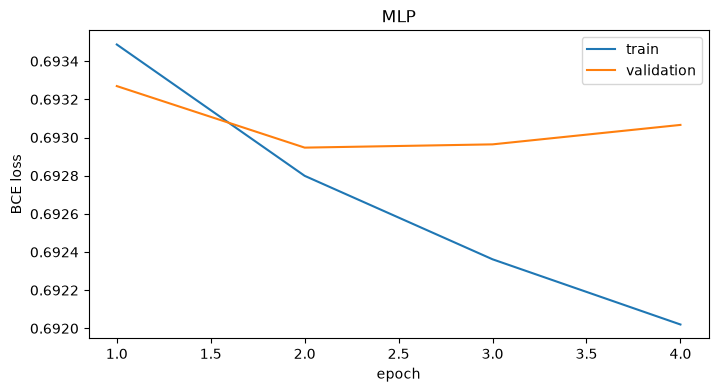

,epoch,train_loss,train_auc,train_prob_std,val_loss,val_auc,val_prob_std,META_auc,grad_norm
0,1,0.693024,0.514297,0.020964,0.692647,0.517434,0.018953,0.517434,0.062672
1,2,0.692400,0.522872,0.022478,0.692447,0.520417,0.020625,0.520417,0.038925
2,3,0.692082,0.526331,0.023476,0.692373,0.521844,0.022754,0.521844,0.054944
3,4,0.692014,0.527253,0.025086,0.692245,0.523676,0.022029,0.523676,0.040972
4,5,0.691851,0.529174,0.025023,0.692240,0.523623,0.024682,0.523623,0.040445
5,6,0.691748,0.529951,0.026163,0.692151,0.524341,0.025062,0.524341,0.037484
6,7,0.691704,0.530588,0.026901,0.692139,0.524788,0.024923,0.524788,0.032538
7,8,0.691660,0.531084,0.026870,0.692082,0.525495,0.025580,0.525495,0.051216
8,9,0.691540,0.532106,0.027524,0.692137,0.525304,0.027211,0.525304,0.063005
9,10,0.691518,0.532249,0.028564,0.692093,0.525831,0.026797,0.525831,0.055408


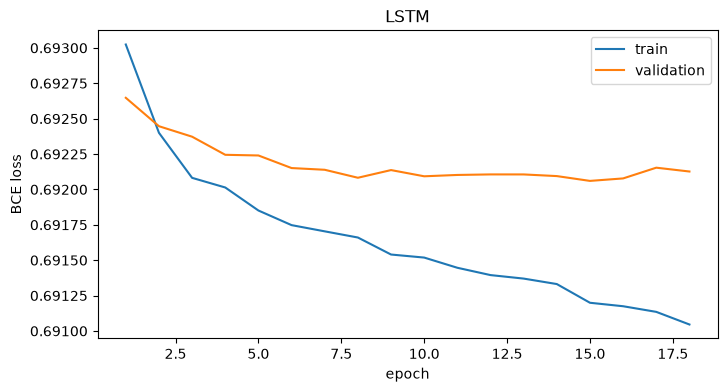

,epoch,train_loss,train_auc,train_prob_std,val_loss,val_auc,val_prob_std,META_auc,grad_norm
0,1,0.693854,0.514199,0.033829,0.692459,0.520213,0.020723,0.520213,0.107727
1,2,0.692911,0.520238,0.030485,0.692321,0.522267,0.022671,0.522267,0.096711
2,3,0.692654,0.522579,0.029910,0.692220,0.523492,0.023398,0.523492,0.110942
3,4,0.692433,0.524120,0.029148,0.692289,0.522994,0.024613,0.522994,0.090937
4,5,0.692268,0.525799,0.029076,0.692172,0.524451,0.024100,0.524451,0.091061
5,6,0.692267,0.525512,0.028875,0.692257,0.523715,0.024300,0.523715,0.068830
6,7,0.692065,0.527185,0.027765,0.692224,0.524722,0.025577,0.524722,0.102185
7,8,0.692039,0.527429,0.028059,0.692148,0.525090,0.024612,0.525090,0.049171
8,9,0.691911,0.528927,0.027912,0.692225,0.525072,0.024996,0.525072,0.066619
9,10,0.691861,0.529056,0.028092,0.692074,0.525753,0.024827,0.525753,0.059717


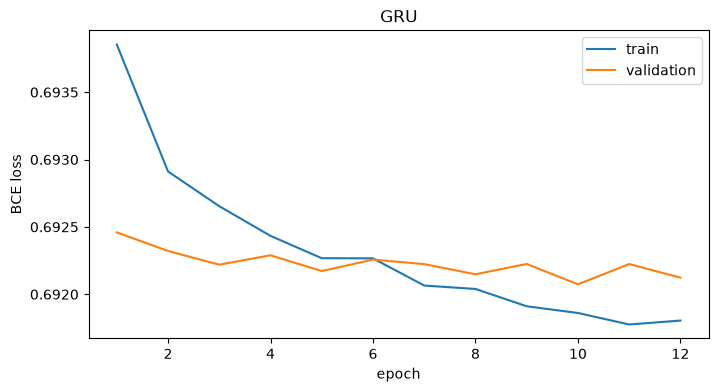

,epoch,train_loss,train_auc,train_prob_std,val_loss,val_auc,val_prob_std,META_auc,grad_norm
0,1,0.693180,0.505071,0.010245,0.693199,0.503450,0.010164,0.503450,0.055707
1,2,0.693084,0.507436,0.009751,0.693154,0.505281,0.006817,0.505281,0.042477
2,3,0.693042,0.508946,0.008903,0.693144,0.504617,0.008262,0.504617,0.072050
3,4,0.693023,0.509391,0.009373,0.693074,0.505875,0.006555,0.505875,0.023283
4,5,0.692990,0.510215,0.009084,0.693061,0.506013,0.006499,0.506013,0.023843
5,6,0.692966,0.511059,0.009898,0.693100,0.506529,0.007222,0.506529,0.019195
6,7,0.692952,0.511410,0.009563,0.693167,0.506990,0.008648,0.506990,0.018416
7,8,0.692937,0.511774,0.009834,0.693190,0.507618,0.010876,0.507618,0.063541
8,9,0.692907,0.512612,0.010482,0.693033,0.507996,0.008237,0.507996,0.025718
9,10,0.692842,0.514220,0.011270,0.693021,0.509119,0.007131,0.509119,0.018797


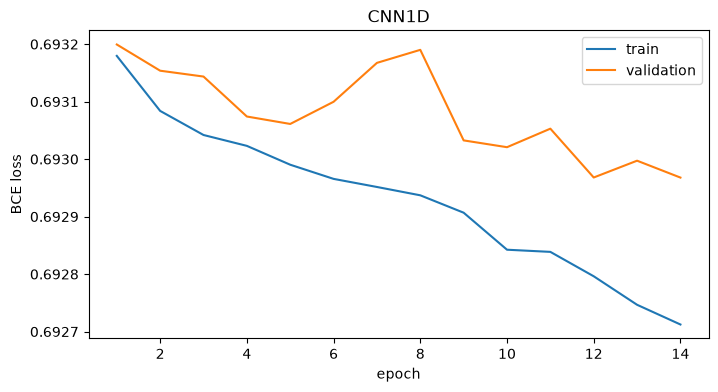

,epoch,train_loss,train_auc,train_prob_std,val_loss,val_auc,val_prob_std,META_auc,grad_norm
0,1,0.692897,0.514427,0.012106,0.692738,0.516236,0.013287,0.516236,0.052221
1,2,0.692381,0.523105,0.018338,0.692578,0.519672,0.019612,0.519672,0.036092
2,3,0.692177,0.525371,0.021494,0.692537,0.521165,0.023009,0.521165,0.054264
3,4,0.691951,0.528068,0.023869,0.692384,0.522668,0.023359,0.522668,0.052896
4,5,0.691815,0.529668,0.025422,0.692318,0.523804,0.023312,0.523804,0.045749
5,6,0.691679,0.530939,0.026079,0.692351,0.523841,0.025964,0.523841,0.055045
6,7,0.691592,0.531735,0.026755,0.692280,0.524231,0.025659,0.524231,0.050424
7,8,0.691464,0.532842,0.028260,0.692297,0.523856,0.025094,0.523856,0.062796
8,9,0.691343,0.534252,0.028852,0.692305,0.523818,0.024852,0.523818,0.061278


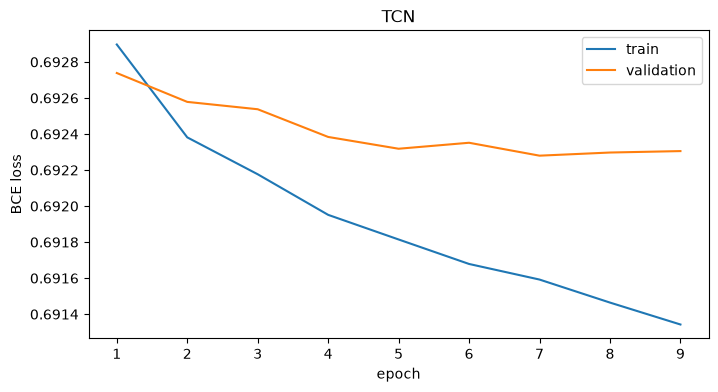

,epoch,train_loss,train_auc,train_prob_std,val_loss,val_auc,val_prob_std,META_auc,grad_norm
0,1,0.698414,0.504803,0.054194,0.692425,0.521735,0.023880,0.521735,1.394372
1,2,0.694182,0.513153,0.036770,0.692203,0.524567,0.021924,0.524567,0.180227
2,3,0.693192,0.518182,0.032736,0.692144,0.524634,0.023838,0.524634,0.176188
3,4,0.692831,0.520838,0.031022,0.692338,0.524621,0.025347,0.524621,0.174491
4,5,0.692650,0.522100,0.030263,0.691997,0.526311,0.023979,0.526311,0.144374
5,6,0.692308,0.524652,0.029863,0.692059,0.526702,0.027356,0.526702,0.153636
6,7,0.692114,0.526215,0.030288,0.692223,0.526013,0.028039,0.526013,0.093541
7,8,0.691921,0.528208,0.031153,0.691870,0.528783,0.025749,0.528783,0.111099
8,9,0.691801,0.528873,0.030936,0.692061,0.528455,0.028880,0.528455,0.094020
9,10,0.691580,0.530083,0.031648,0.691885,0.528713,0.030366,0.528713,0.202830


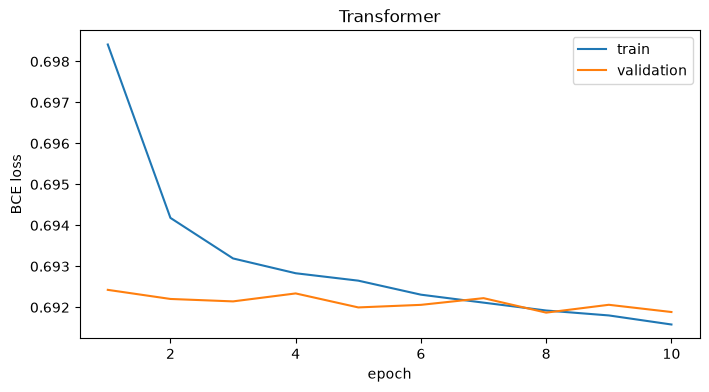

In [13]:
import matplotlib.pyplot as plt

for name,h in histories.items():
    display(h)
    plt.figure(figsize=(8,4))
    plt.plot(h.epoch,h.train_loss,label="train")
    plt.plot(h.epoch,h.val_loss,label="validation")
    plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title(name); plt.legend(); plt.show()

## What a flat loss means in this notebook

Interpret the real training result only after the causal alignment, finite-input, gradient/update, and tiny-real-subset memorization checks pass.

No diagnostic deliberately inserts the target into the model inputs.

If the optimizer/gradient check passes and a small real subset can be memorized, but full-sample validation loss remains near the constant-prior loss with AUC near 0.50, the likely issue is generalization/signal rather than a disconnected training pipeline.

The feature ablation asks a narrower question: **did adding longer relative price context help beyond returns and short-horizon features alone?**

- If the enhanced MLP improves out of sample, the extra state representation is useful.
- If training improves but validation/test do not, the longer-memory features are mostly giving the network more ways to overfit.
- If neither changes, longer price context is probably not the main bottleneck for this target.

The CatBoost baseline remains useful: if CatBoost materially beats the neural models on the same endpoint rows, focus next on neural preprocessing/architecture/regularization. If all model families cluster near the same validation AUC, the feature/target formulation is the more likely bottleneck.


## Final comparison: CatBoost baseline

CatBoost uses the **same supervised endpoint rows** as the sequence models, but receives the original **unscaled engineered features** at the endpoint. Tree models do not require StandardScaler, and `symbol` is passed as a categorical feature.

The feature set in this version includes the relative price-memory features but **no fractional-differentiation feature**.

This makes CatBoost a useful comparison against the neural architectures, although note that CatBoost is using endpoint features rather than the full 78-step tensor.


In [14]:
try:
    from catboost import CatBoostClassifier

    def target_row_ids(ds):
        return np.concatenate([x.target_row_ids for x in ds.datasets])

    def cb_split(raw_df, ds):
        # Match the sequence models' eligible target rows exactly.
        ids = target_row_ids(ds)
        key = pd.DataFrame({"row_id": ids, "_order": np.arange(len(ids))})
        out = (
            key.merge(raw_df, on="row_id", how="left", validate="one_to_one")
               .sort_values("_order")
               .reset_index(drop=True)
        )
        X = out[["symbol"] + FEATURE_COLS].copy()
        y = out["label01"].astype(int).copy()
        return X, y, out

    # IMPORTANT: CatBoost gets RAW engineered features, not NN-scaled features.
    Xtr, ytr, rtr = cb_split(train_df, train_ds)
    Xv, yv, rv = cb_split(val_df, val_ds)
    Xt, yt, rt = cb_split(test_df, test_ds)

    assert not (set(Xtr.columns) & FORBIDDEN_FEATURES)
    assert Xtr[FEATURE_COLS].notna().all().all()
    assert Xv[FEATURE_COLS].notna().all().all()
    assert Xt[FEATURE_COLS].notna().all().all()

    cat_model = CatBoostClassifier(
        iterations=2000,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        l2_leaf_reg=10.0,
        random_seed=SEED,
        cat_features=["symbol"],
        allow_writing_files=False,
        verbose=100,
    )

    cat_model.fit(
        Xtr,
        ytr,
        eval_set=(Xv, yv),
        early_stopping_rounds=150,
        verbose=100,
    )

    pv = cat_model.predict_proba(Xv)[:, 1]
    pt = cat_model.predict_proba(Xt)[:, 1]
    mv = metrics(pv, yv)
    mt = metrics(pt, yt)

    focus_val = rv.symbol.eq(FOCUS_SYMBOL).to_numpy()
    focus_test = rt.symbol.eq(FOCUS_SYMBOL).to_numpy()

    cbrow = {
        "model": "CatBoost",
        "params": np.nan,
        "val_auc": mv["auc"],
        "test_auc": mt["auc"],
        f"{FOCUS_SYMBOL}_val_auc": roc_auc_score(yv[focus_val], pv[focus_val]),
        f"{FOCUS_SYMBOL}_test_auc": roc_auc_score(yt[focus_test], pt[focus_test]),
        "val_bal_acc": mv["balanced_accuracy"],
        "test_bal_acc": mt["balanced_accuracy"],
        "val_prob_std": mv["prob_std"],
        "test_prob_std": mt["prob_std"],
    }

    results_df = (
        pd.concat([results_df, pd.DataFrame([cbrow])], ignore_index=True)
          .sort_values("val_auc", ascending=False)
          .reset_index(drop=True)
    )

    print("Final neural-network + CatBoost comparison:")
    display(results_df)

    # Useful diagnostic: which endpoint features CatBoost relied on most?
    feature_importance_df = pd.DataFrame({
        "feature": Xtr.columns,
        "importance": cat_model.get_feature_importance(),
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    display(feature_importance_df.head(20))

except ImportError:
    print("CatBoost not installed. Install it with: pip install catboost")


0:	test: 0.5245702	best: 0.5245702 (0)	total: 72.4ms	remaining: 2m 24s
100:	test: 0.5271722	best: 0.5273950 (62)	total: 1.24s	remaining: 23.4s
200:	test: 0.5280489	best: 0.5281006 (198)	total: 2.43s	remaining: 21.7s
300:	test: 0.5283960	best: 0.5284110 (294)	total: 3.6s	remaining: 20.3s
400:	test: 0.5288975	best: 0.5289268 (398)	total: 4.78s	remaining: 19.1s
500:	test: 0.5295531	best: 0.5296551 (497)	total: 5.96s	remaining: 17.8s
600:	test: 0.5297461	best: 0.5297533 (598)	total: 7.13s	remaining: 16.6s
700:	test: 0.5299107	best: 0.5299733 (697)	total: 8.31s	remaining: 15.4s
800:	test: 0.5301553	best: 0.5302718 (775)	total: 9.49s	remaining: 14.2s
900:	test: 0.5301085	best: 0.5302718 (775)	total: 10.7s	remaining: 13s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.5302718192
bestIteration = 775

Shrink model to first 776 iterations.
Final neural-network + CatBoost comparison:


,model,params,val_auc,test_auc,META_val_auc,META_test_auc,val_bal_acc,test_bal_acc,val_prob_std,test_prob_std
0,CatBoost,NaN,0.530272,0.531812,0.530272,0.531812,0.519875,0.520192,0.029401,0.030451
1,Transformer,74242.0,0.528783,0.530250,0.528783,0.530250,0.519506,0.520478,0.025749,0.027154
2,LSTM,25154.0,0.526310,0.528563,0.526310,0.528563,0.517822,0.518969,0.027466,0.026953
3,GRU,18882.0,0.525753,0.530355,0.525753,0.530355,0.517436,0.521797,0.024827,0.024802
4,TCN,30978.0,0.524231,0.529784,0.524231,0.529784,0.517948,0.519835,0.025659,0.025335
5,MLP,327938.0,0.514169,0.513493,0.514169,0.513493,0.511383,0.509812,0.015004,0.015184
6,CNN1D,30914.0,0.511011,0.507748,0.511011,0.507748,0.505385,0.506471,0.009222,0.009829


,feature,importance
0,close_location,10.035295
1,close_vs_average,4.835745
2,ret_2,4.278921
3,gap_from_prev_close,3.660246
4,log_volume,3.604862
5,tod_cos,3.590283
6,log_close_vs_ma_20d,3.578893
7,range_pct,3.493063
8,log_close_vs_ma_30m,3.427459
9,relative_volume_5,3.345426


## Scope boundary

This notebook deliberately stops at the results reported in the article. A credible trading follow-up still needs repeated seeds, walk-forward folds, multiple symbols, calibration, a predeclared decision rule, and realistic spread, fee, slippage, latency, turnover, and drawdown analysis.
